In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix, RocCurveDisplay

from imblearn.over_sampling import SMOTE

import xgboost as xgb
import lightgbm as lgb
import optuna
import shap

import joblib
import warnings
warnings.filterwarnings('ignore')

print('Setup complete')

Setup complete


In [2]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

print('Train:', train.shape)
print('Test:', test.shape)

Train: (165034, 14)
Test: (110023, 13)


In [3]:
train.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [4]:
train['Exited'].value_counts()

Exited
0    130113
1     34921
Name: count, dtype: int64

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  str    
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  str    
 5   Gender           165034 non-null  str    
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), str(3)
memory usage: 20.4 MB


In [6]:
train.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


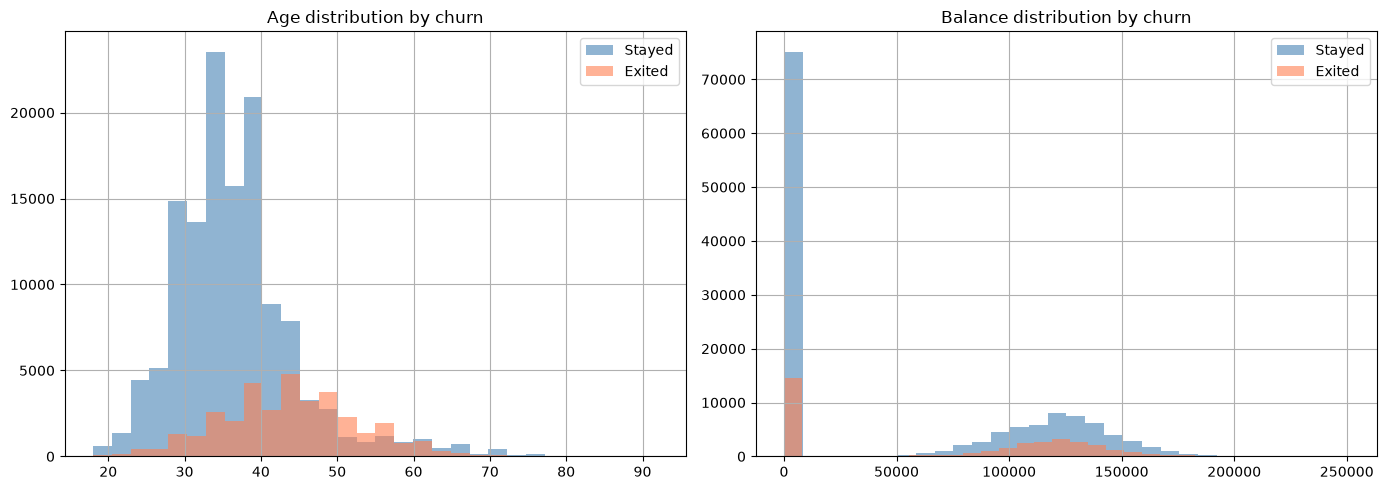

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train[train['Exited']==0]['Age'].hist(bins=30, alpha=0.6, label='Stayed', ax=axes[0], color='steelblue')
train[train['Exited']==1]['Age'].hist(bins=30, alpha=0.6, label='Exited', ax=axes[0], color='coral')
axes[0].set_title('Age distribution by churn')
axes[0].legend()

train[train['Exited']==0]['Balance'].hist(bins=30, alpha=0.6, label='Stayed', ax=axes[1], color='steelblue')
train[train['Exited']==1]['Balance'].hist(bins=30, alpha=0.6, label='Exited', ax=axes[1], color='coral')
axes[1].set_title('Balance distribution by churn')
axes[1].legend()

plt.tight_layout()
plt.show()

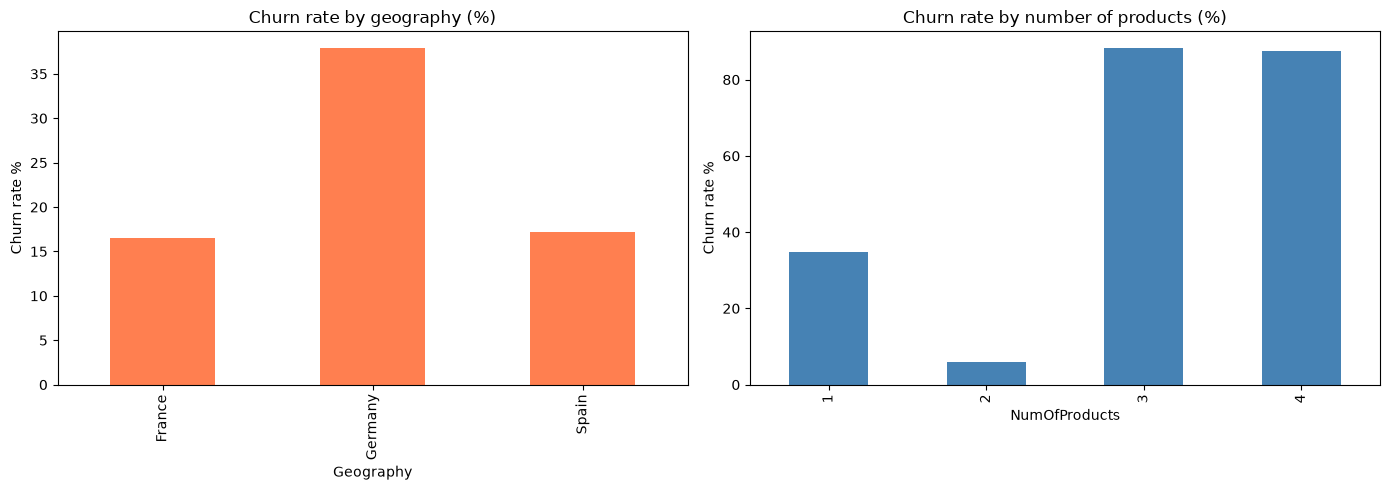

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

churn_by_geo = train.groupby('Geography')['Exited'].mean() * 100
churn_by_geo.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Churn rate by geography (%)')
axes[0].set_ylabel('Churn rate %')

churn_by_products = train.groupby('NumOfProducts')['Exited'].mean() * 100
churn_by_products.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Churn rate by number of products (%)')
axes[1].set_ylabel('Churn rate %')

plt.tight_layout()
plt.show()

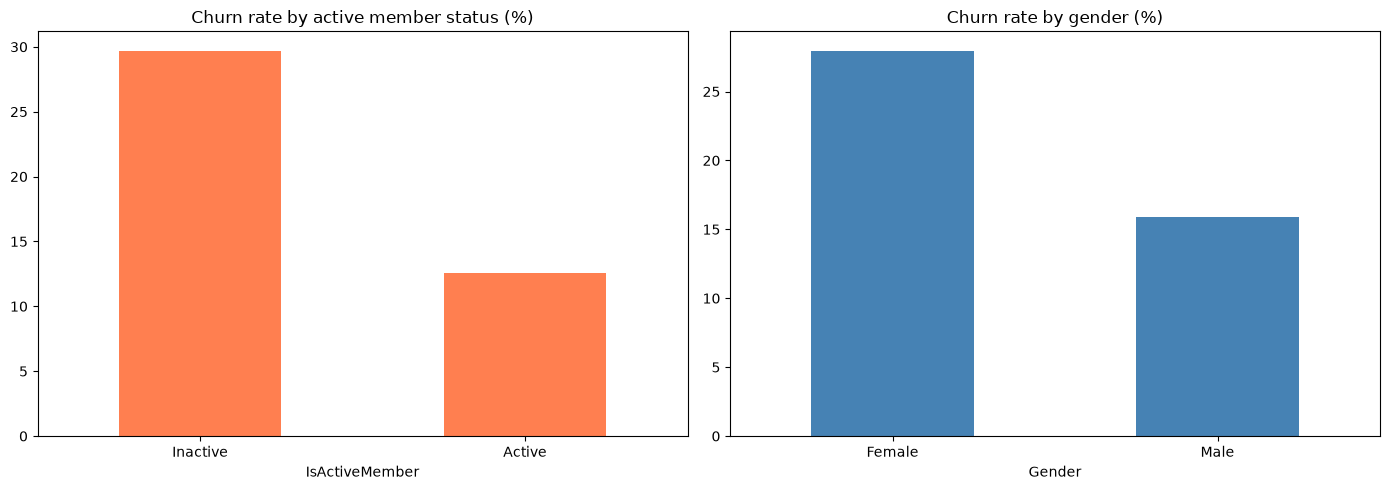

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

churn_by_active = train.groupby('IsActiveMember')['Exited'].mean() * 100
churn_by_active.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Churn rate by active member status (%)')
axes[0].set_xticklabels(['Inactive', 'Active'], rotation=0)

churn_by_gender = train.groupby('Gender')['Exited'].mean() * 100
churn_by_gender.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Churn rate by gender (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

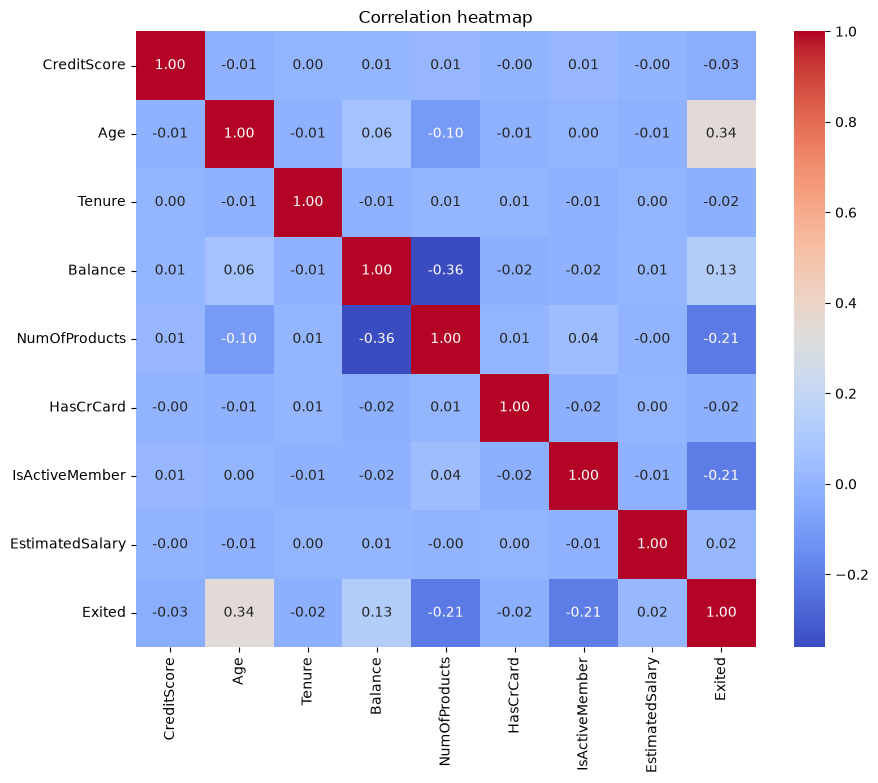

In [10]:
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 
                 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

plt.figure(figsize=(10, 8))
sns.heatmap(train[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation heatmap')
plt.show()

In [11]:
train_clean = train.drop(columns=['id', 'CustomerId', 'Surname'])

print('Shape after dropping columns:', train_clean.shape)

Shape after dropping columns: (165034, 11)


In [12]:
X = train_clean.drop(columns=['Exited'])
y = train_clean['Exited']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (165034, 10)
y shape: (165034,)


In [13]:
X = pd.get_dummies(X, columns=['Geography', 'Gender'], drop_first=True)

print('Shape after encoding:', X.shape)
print(X.columns.tolist())

Shape after encoding: (165034, 11)
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train:', X_train.shape)
print('Test:', X_test.shape)
print('Train churn rate:', y_train.mean())
print('Test churn rate:', y_test.mean())

Train: (132027, 11)
Test: (33007, 11)
Train churn rate: 0.21160065744128095
Test churn rate: 0.2115914805950253


In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Scaling done')

Scaling done


In [16]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

roc_auc_lr = roc_auc_score(y_test, y_proba_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f'Logistic Regression:')
print(f'  ROC-AUC: {roc_auc_lr:.4f}')
print(f'  F1:      {f1_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr))

Logistic Regression:
  ROC-AUC: 0.8145
  F1:      0.4921

              precision    recall  f1-score   support

           0       0.85      0.95      0.90     26023
           1       0.69      0.38      0.49      6984

    accuracy                           0.83     33007
   macro avg       0.77      0.67      0.70     33007
weighted avg       0.82      0.83      0.81     33007



In [17]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print('Before SMOTE:', y_train.value_counts().to_dict())
print('After SMOTE:', y_train_smote.value_counts().to_dict())


Before SMOTE: {0: 104090, 1: 27937}
After SMOTE: {0: 104090, 1: 104090}


In [18]:
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)

y_pred_lr_smote = lr_smote.predict(X_test_scaled)
y_proba_lr_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]

roc_auc_lr_smote = roc_auc_score(y_test, y_proba_lr_smote)
f1_lr_smote = f1_score(y_test, y_pred_lr_smote)

print(f'Logistic Regression + SMOTE:')
print(f'  ROC-AUC: {roc_auc_lr_smote:.4f}')
print(f'  F1:      {f1_lr_smote:.4f}')
print()
print(classification_report(y_test, y_pred_lr_smote))

Logistic Regression + SMOTE:
  ROC-AUC: 0.8160
  F1:      0.5602

              precision    recall  f1-score   support

           0       0.91      0.76      0.83     26023
           1       0.45      0.73      0.56      6984

    accuracy                           0.76     33007
   macro avg       0.68      0.75      0.70     33007
weighted avg       0.82      0.76      0.77     33007



In [19]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    random_state=42,
    eval_metric='auc'
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print(f'XGBoost:')
print(f'  ROC-AUC: {roc_auc_xgb:.4f}')
print(f'  F1:      {f1_xgb:.4f}')
print()
print(classification_report(y_test, y_pred_xgb))

XGBoost:
  ROC-AUC: 0.8836
  F1:      0.6331

              precision    recall  f1-score   support

           0       0.89      0.94      0.92     26023
           1       0.73      0.56      0.63      6984

    accuracy                           0.86     33007
   macro avg       0.81      0.75      0.77     33007
weighted avg       0.85      0.86      0.86     33007



In [20]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print('Scale pos weight:', scale_pos_weight)

xgb_weighted = xgb.XGBClassifier(
    n_estimators=200,
    random_state=42,
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight
)
xgb_weighted.fit(X_train, y_train)

y_pred_xgbw = xgb_weighted.predict(X_test)
y_proba_xgbw = xgb_weighted.predict_proba(X_test)[:, 1]

roc_auc_xgbw = roc_auc_score(y_test, y_proba_xgbw)
f1_xgbw = f1_score(y_test, y_pred_xgbw)

print(f'XGBoost + scale_pos_weight:')
print(f'  ROC-AUC: {roc_auc_xgbw:.4f}')
print(f'  F1:      {f1_xgbw:.4f}')
print()
print(classification_report(y_test, y_pred_xgbw))

Scale pos weight: 3.7258832372838886
XGBoost + scale_pos_weight:
  ROC-AUC: 0.8813
  F1:      0.6432

              precision    recall  f1-score   support

           0       0.93      0.84      0.88     26023
           1       0.56      0.76      0.64      6984

    accuracy                           0.82     33007
   macro avg       0.74      0.80      0.76     33007
weighted avg       0.85      0.82      0.83     33007



In [21]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)
y_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

roc_auc_lgb = roc_auc_score(y_test, y_proba_lgb)
f1_lgb = f1_score(y_test, y_pred_lgb)

print(f'LightGBM:')
print(f'  ROC-AUC: {roc_auc_lgb:.4f}')
print(f'  F1:      {f1_lgb:.4f}')
print()
print(classification_report(y_test, y_pred_lgb))

LightGBM:
  ROC-AUC: 0.8891
  F1:      0.6384

              precision    recall  f1-score   support

           0       0.89      0.95      0.92     26023
           1       0.74      0.56      0.64      6984

    accuracy                           0.87     33007
   macro avg       0.82      0.75      0.78     33007
weighted avg       0.86      0.87      0.86     33007



In [22]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'verbose': -1
    }
    
    model = lgb.LGBMClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print('Best ROC-AUC:', study.best_value)
print('Best params:', study.best_params)

[I 2026-09-19 13:41:14,790] A new study created in memory with name: no-name-957a595c-dde4-40c7-9d45-b792dd94694a


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-09-19 13:41:20,940] Trial 0 finished with value: 0.8890347051476717 and parameters: {'n_estimators': 492, 'max_depth': 4, 'learning_rate': 0.07868073264049456, 'num_leaves': 82, 'min_child_samples': 68, 'subsample': 0.687501527395085, 'colsample_bytree': 0.8588807699765084}. Best is trial 0 with value: 0.8890347051476717.
[I 2026-09-19 13:41:44,797] Trial 1 finished with value: 0.8666497610504283 and parameters: {'n_estimators': 445, 'max_depth': 9, 'learning_rate': 0.263039221607295, 'num_leaves': 113, 'min_child_samples': 81, 'subsample': 0.9318153928439583, 'colsample_bytree': 0.8303715504109255}. Best is trial 0 with value: 0.8890347051476717.
[I 2026-09-19 13:41:54,011] Trial 2 finished with value: 0.8893438955551234 and parameters: {'n_estimators': 404, 'max_depth': 5, 'learning_rate': 0.027674181488969336, 'num_leaves': 146, 'min_child_samples': 63, 'subsample': 0.9522255471279342, 'colsample_bytree': 0.7460463909563512}. Best is trial 2 with value: 0.8893438955551234.
[

In [24]:
best_params = {
    'n_estimators': 274,
    'max_depth': 5,
    'learning_rate': 0.05433062007888886,
    'num_leaves': 28,
    'min_child_samples': 55,
    'subsample': 0.949495553166147,
    'colsample_bytree': 0.6234830776780291,
    'random_state': 42,
    'verbose': -1
}

final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)[:, 1]

roc_auc_final = roc_auc_score(y_test, y_proba_final)
f1_final = f1_score(y_test, y_pred_final)

print(f'Final tuned LightGBM:')
print(f'  ROC-AUC: {roc_auc_final:.4f}')
print(f'  F1:      {f1_final:.4f}')
print()
print(classification_report(y_test, y_pred_final))

Final tuned LightGBM:
  ROC-AUC: 0.8900
  F1:      0.6342

              precision    recall  f1-score   support

           0       0.89      0.95      0.92     26023
           1       0.75      0.55      0.63      6984

    accuracy                           0.87     33007
   macro avg       0.82      0.75      0.78     33007
weighted avg       0.86      0.87      0.86     33007



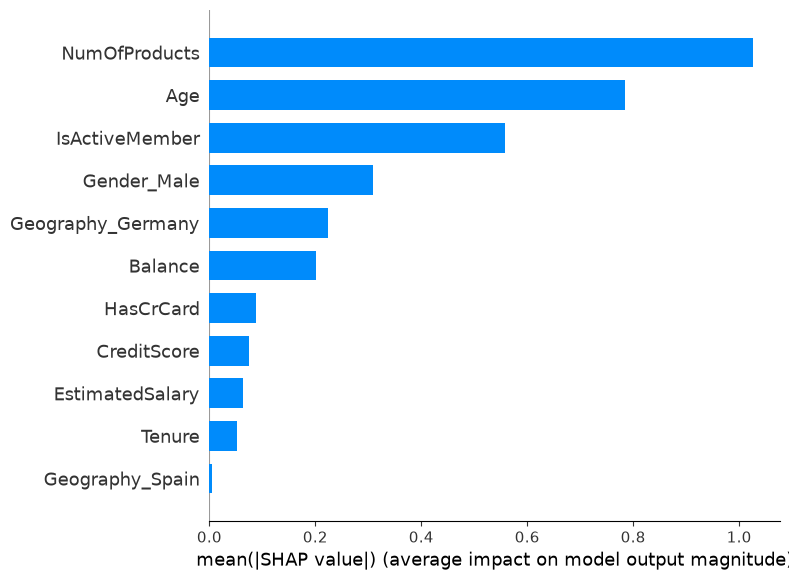

In [25]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type='bar')

In [26]:
import os
os.makedirs('models', exist_ok=True)

joblib.dump(final_model, 'models/model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(X.columns.tolist(), 'models/feature_columns.pkl')

print('Model, scaler i lista kolumn zapisane.')

Model, scaler i lista kolumn zapisane.


In [27]:
test_ids = test['id']
test_processed = test.drop(columns=['id', 'CustomerId', 'Surname'])
test_processed = pd.get_dummies(test_processed, columns=['Geography', 'Gender'], drop_first=True)

# Align columns with train (in case some category is missing in test)
test_processed = test_processed.reindex(columns=X.columns, fill_value=0)

predictions_proba = final_model.predict_proba(test_processed)[:, 1]

submission = pd.DataFrame({
    'id': test_ids,
    'Exited': predictions_proba
})

submission.to_csv('submission.csv', index=False)
print('Submission saved.')
print(submission.head())

Submission saved.
       id    Exited
0  165034  0.024005
1  165035  0.806399
2  165036  0.029624
3  165037  0.235766
4  165038  0.386021
